# Matrix Completion

Matrix Completion is an unsupervised learning technique used to recover missing entries of a matrix from the observed entries.

The central idea is that a matrix with many missing values may still have an underlying low-dimensional structure.

For example, consider a user-item rating matrix:

- Rows represent users.
- Columns represent movies.
- Each entry represents a rating.
- Many ratings are missing because users have not rated every movie.

The goal is to estimate these missing values using the information contained in the observed values.

Matrix Completion is closely related to:

- Matrix Factorization
- Low-Rank Approximation
- Collaborative Filtering
- Recommender Systems
- Dimensionality Reduction
- Missing Data Imputation

The key assumption is:

> The complete matrix is approximately low-rank.

## 1. Motivation

Suppose we have a matrix containing user ratings:

$$
R =
\begin{bmatrix}
5 & ? & 3 & ? \\
4 & 2 & ? & ? \\
? & 5 & 4 & 1 \\
2 & ? & ? & 5
\end{bmatrix}
$$

Here, `?` represents a missing value.

A simple approach would be to replace missing values with:

- Mean
- Median
- Zero
- Row mean
- Column mean

However, these methods ignore relationships between users and items.

Matrix Completion attempts to understand the hidden structure of the matrix and use that structure to estimate the missing entries.

## 2. What is the Matrix Completion Problem?

Let the unknown complete matrix be:

$$
X \in \mathbb{R}^{m \times n}
$$

where:

- $m$ = number of rows
- $n$ = number of columns

We only observe some entries of $X$.

Let:

$$
\Omega
$$

denote the set of indices corresponding to observed entries.

For example:

$$
\Omega = \{(1,1), (1,3), (2,1), (2,2), \ldots\}
$$

The matrix completion problem is to estimate the full matrix $X$ using only the observed entries.

The estimated matrix should satisfy two requirements:

1. It should agree with the observed values.
2. It should have a simple underlying structure, usually a low-rank structure.

## 3. Observed Entries

Define the observation operator:

$$
P_{\Omega}(X)
$$

which keeps the entries belonging to $\Omega$ and sets all other entries to zero.

For example:

$$
X =
\begin{bmatrix}
5 & 4 & 3 \\
4 & 2 & 1 \\
3 & 5 & 4
\end{bmatrix}
$$

Suppose only some entries are observed.

Then:

$$
P_{\Omega}(X)
=
\begin{bmatrix}
5 & 0 & 3 \\
4 & 2 & 0 \\
0 & 5 & 4
\end{bmatrix}
$$

Matrix Completion uses the observed entries to reconstruct the missing ones.

## 4. Why Low-Rank Structure?

Many real-world matrices have hidden low-dimensional structure.

For example, a movie-rating matrix may contain thousands of users and thousands of movies, but user preferences may depend on a relatively small number of latent factors.

Possible latent factors could represent:

- Action preference
- Comedy preference
- Romance preference
- Popularity
- Movie quality
- Age-related preference

Therefore, a large matrix can sometimes be represented using a small number of latent factors.

This leads to the assumption:

$$
\operatorname{rank}(X) \ll \min(m,n)
$$

Such a matrix is called a low-rank matrix.

Matrix Completion tries to recover this low-rank structure from incomplete observations.

## 6. Intuition Behind Matrix Factorization

Suppose we have:

$$
U =
\begin{bmatrix}
u_1^T \\
u_2^T \\
\vdots \\
u_m^T
\end{bmatrix}
$$

and:

$$
V =
\begin{bmatrix}
v_1^T \\
v_2^T \\
\vdots \\
v_n^T
\end{bmatrix}
$$

Then an individual matrix entry is estimated as:

$$
\hat{X}_{ij} = u_i^T v_j
$$

or equivalently:

$$
\hat{X}_{ij}
=
\sum_{l=1}^{k} U_{il}V_{jl}
$$

Therefore, the predicted value depends on the interaction between the latent representation of row $i$ and column $j$.

This allows us to predict entries that were originally missing.

## 7. Matrix Completion Objective

Since only observed entries are available, we should calculate the reconstruction error only on those entries.

The basic objective is:

$$
\min_{U,V}
\sum_{(i,j)\in\Omega}
\left(
X_{ij} - U_i^T V_j
\right)^2
$$

where:

- $\Omega$ = observed entries
- $X_{ij}$ = observed value
- $U_i$ = latent representation of row $i$
- $V_j$ = latent representation of column $j$

The important point is:

> Missing entries do not contribute directly to the loss.

## 8. Regularized Matrix Completion

Without regularization, the model may overfit the observed entries.

We therefore add regularization:

$$
\min_{U,V}
\sum_{(i,j)\in\Omega}
\left(
X_{ij} - U_i^T V_j
\right)^2
+
\lambda
\left(
\|U\|_F^2 + \|V\|_F^2
\right)
$$

where:

- $\lambda$ = regularization strength
- $\|U\|_F$ = Frobenius norm of $U$
- $\|V\|_F$ = Frobenius norm of $V$

The first term minimizes reconstruction error.

The second term prevents excessively large latent factors.

Therefore, regularization helps improve generalization to unseen entries.

## 9. Frobenius Norm

The Frobenius norm of a matrix is:

$$
\|U\|_F
=
\sqrt{
\sum_{i,j} U_{ij}^2
}
$$

Therefore:

$$
\|U\|_F^2
=
\sum_{i,j} U_{ij}^2
$$

The regularization term:

$$
\lambda
\left(
\|U\|_F^2 + \|V\|_F^2
\right)
$$

penalizes large values in the latent factor matrices.

## 10. Rank Minimization

An ideal formulation would directly minimize the rank of the completed matrix:

$$
\min_X \operatorname{rank}(X)
$$

subject to:

$$
P_{\Omega}(X)
=
P_{\Omega}(M)
$$

where $M$ contains the observed values.

However, rank minimization is computationally difficult because the rank function is non-convex.

Therefore, a convex relaxation is commonly used.

## 11. Nuclear Norm

The nuclear norm of a matrix is defined as the sum of its singular values:

$$
\|X\|_*
=
\sum_i \sigma_i(X)
$$

where $\sigma_i(X)$ are the singular values of $X$.

The matrix completion problem can therefore be formulated as:

$$
\min_X \|X\|_*
$$

subject to:

$$
P_{\Omega}(X)
=
P_{\Omega}(M)
$$

The nuclear norm acts as a convex surrogate for matrix rank.

Therefore:

$$
\text{Low Rank}
\quad \longleftrightarrow \quad
\text{Small Nuclear Norm}
$$

## 12. Two Important Approaches

There are two major ways to think about Matrix Completion.

### 1. Matrix Factorization

Represent the matrix as:

$$
X \approx UV^T
$$

and optimize the latent factors $U$ and $V$.

Advantages:

- Efficient for large problems
- Directly learns latent representations
- Common in recommender systems

### 2. Nuclear Norm Minimization

Directly optimize:

$$
\min_X \|X\|_*
$$

subject to matching the observed entries.

Advantages:

- Convex optimization formulation
- Strong theoretical foundations
- Directly encourages low rank

In practical recommender systems, matrix factorization is often more computationally attractive.

# 13. Practical Example

We will create a synthetic low-rank matrix and hide some of its entries.

The goal is to:

1. Generate a low-rank matrix.
2. Remove some entries.
3. Learn latent factors from observed entries.
4. Reconstruct the complete matrix.
5. Compare reconstructed values with the original values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

np.random.seed(42)

## 14. Generate a Low-Rank Matrix

We first generate two latent factor matrices.

Their product produces the original complete matrix.

$$
X = UV^T
$$

Because the number of latent factors is small, the resulting matrix has low rank.

In [2]:
n_rows = 20
n_cols = 15
n_factors = 3

U_true = np.random.normal(
    size=(n_rows, n_factors)
)

V_true = np.random.normal(
    size=(n_cols, n_factors)
)

X_true = U_true @ V_true.T

X_true.shape

(20, 15)

In [3]:
X_true[:5, :5]

array([[-0.9289031 ,  0.17190505,  0.05970629,  0.62576043, -1.93090854],
       [-0.42729009, -2.32965998, -0.42932654, -1.42726985,  0.19244843],
       [-0.37980331, -1.90222425,  0.48664784, -1.46350262,  2.37408816],
       [ 0.34130997, -1.65719409, -0.67254937, -1.23380271,  0.47557191],
       [ 2.14761249, -4.18342909, -2.56125583, -3.50053241,  1.5165747 ]])

## 15. Create Missing Entries

We randomly hide a large portion of the matrix.

The observed entries will be used for training.

The hidden entries will be used for evaluating the quality of the completion.

In [4]:
observed_fraction = 0.5

mask = np.random.rand(
    n_rows,
    n_cols
) < observed_fraction

X_observed = X_true.copy()

X_observed[~mask] = np.nan

X_observed[:5, :5]

array([[        nan,         nan,  0.05970629,         nan,         nan],
       [-0.42729009, -2.32965998, -0.42932654,         nan,  0.19244843],
       [-0.37980331, -1.90222425,  0.48664784,         nan,         nan],
       [ 0.34130997,         nan,         nan, -1.23380271,         nan],
       [        nan,         nan,         nan,         nan,         nan]])

## 16. Visualize Missing Data

A useful way to understand Matrix Completion is to visualize which entries are observed and which are missing.

Observed entries:

$$
M_{ij} = 1
$$

Missing entries:

$$
M_{ij} = 0
$$

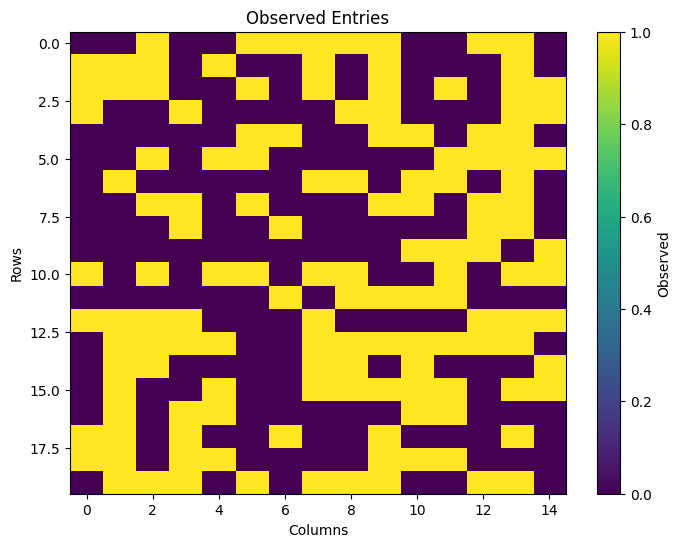

In [5]:
plt.figure(figsize=(8, 6))

plt.imshow(mask, aspect="auto")

plt.xlabel("Columns")
plt.ylabel("Rows")
plt.title("Observed Entries")

plt.colorbar(label="Observed")

plt.show()

# 17. Matrix Completion Using Matrix Factorization

We now learn the latent matrices $U$ and $V$ directly.

The objective is:

$$
L(U,V)
=
\sum_{(i,j)\in\Omega}
\left(
X_{ij} - U_i^T V_j
\right)^2
+
\lambda
\left(
\|U\|_F^2 + \|V\|_F^2
\right)
$$

We can minimize this objective using gradient descent.

The predicted matrix is:

$$
\hat{X} = UV^T
$$

## 18. Gradients

For an observed entry $(i,j)$, define the prediction error:

$$
e_{ij}
=
X_{ij} - U_i^T V_j
$$

The gradient with respect to $U_i$ is:

$$
\frac{\partial L}{\partial U_i}
=
-2e_{ij}V_j
+
2\lambda U_i
$$

The gradient with respect to $V_j$ is:

$$
\frac{\partial L}{\partial V_j}
=
-2e_{ij}U_i
+
2\lambda V_j
$$

We update the latent factors repeatedly until the reconstruction error becomes small.

In [6]:
def matrix_completion(
    X,
    mask,
    n_factors=3,
    learning_rate=0.01,
    regularization=0.01,
    n_epochs=1000
):
    n_rows, n_cols = X.shape

    U = np.random.normal(
        scale=0.1,
        size=(n_rows, n_factors)
    )

    V = np.random.normal(
        scale=0.1,
        size=(n_cols, n_factors)
    )

    observed_indices = np.argwhere(mask)

    losses = []

    for epoch in range(n_epochs):

        np.random.shuffle(observed_indices)

        for i, j in observed_indices:

            error = X[i, j] - np.dot(U[i], V[j])

            U_i = U[i].copy()
            V_j = V[j].copy()

            U[i] += learning_rate * (
                error * V_j
                - regularization * U_i
            )

            V[j] += learning_rate * (
                error * U_i
                - regularization * V_j
            )

        reconstructed = U @ V.T

        observed_error = (
            (X[mask] - reconstructed[mask]) ** 2
        ).mean()

        losses.append(observed_error)

    return U, V, losses

## 19. Train the Matrix Completion Model

We train the model using only the observed entries.

The missing values are not used during optimization.

In [7]:
X_filled_for_training = np.nan_to_num(
    X_observed,
    nan=0.0
)

U_est, V_est, losses = matrix_completion(
    X_filled_for_training,
    mask,
    n_factors=3,
    learning_rate=0.01,
    regularization=0.01,
    n_epochs=1000
)

X_completed = U_est @ V_est.T

X_completed[:5, :5]

array([[-0.78180484,  0.23047163,  0.06938304,  0.67903485, -1.44697412],
       [-0.43563636, -2.26894806, -0.44319592, -1.22560503,  0.23229606],
       [-0.36278007, -1.86539816,  0.48492426, -1.3177804 ,  2.46940036],
       [ 0.33184471, -1.63928097, -0.68341671, -1.19258494,  0.35534592],
       [ 1.69120113, -3.57758598, -2.49499191, -2.89217958, -0.18343716]])

## 20. Training Loss

The training loss measures reconstruction error on the observed entries.

A decreasing loss generally indicates that the optimization procedure is learning the latent structure of the matrix.

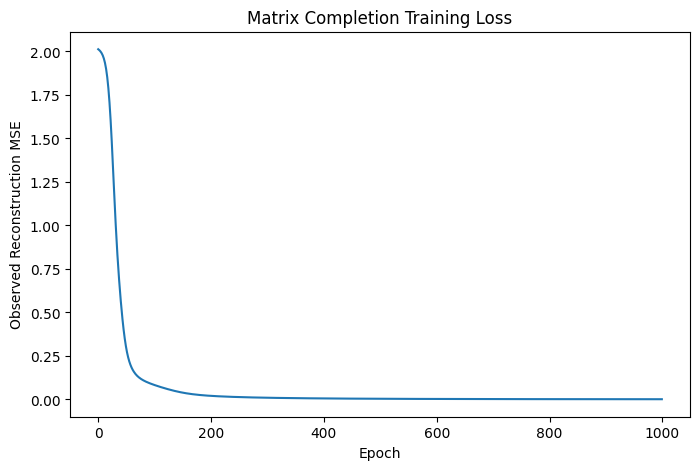

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Observed Reconstruction MSE")
plt.title("Matrix Completion Training Loss")

plt.show()

# 21. Evaluating Matrix Completion

We should not evaluate only on the entries used for training.

The most important test is:

> How accurately can the model reconstruct entries that were hidden?

Because we generated the original matrix ourselves, we know the true values of the missing entries.

Therefore, we can calculate:

$$
MSE_{\text{missing}}
=
\frac{1}{|\Omega^c|}
\sum_{(i,j)\notin\Omega}
\left(
X_{ij} - \hat{X}_{ij}
\right)^2
$$

In [9]:
missing_mask = ~mask

missing_mse = mean_squared_error(
    X_true[missing_mask],
    X_completed[missing_mask]
)

missing_rmse = np.sqrt(missing_mse)

missing_mse, missing_rmse

(0.08080505885609139, np.float64(0.28426230642857203))

## 22. Observed vs Missing Reconstruction Error

It is useful to compare:

- Error on observed entries
- Error on missing entries

A large difference between these two errors can indicate overfitting.

In [10]:
observed_mse = mean_squared_error(
    X_true[mask],
    X_completed[mask]
)

missing_mse = mean_squared_error(
    X_true[~mask],
    X_completed[~mask]
)

print("Observed MSE:", observed_mse)
print("Missing MSE:", missing_mse)

Observed MSE: 0.0013772164156483264
Missing MSE: 0.08080505885609139


## 23. Visualize the Original Matrix

The original matrix represents the complete data before entries were removed.

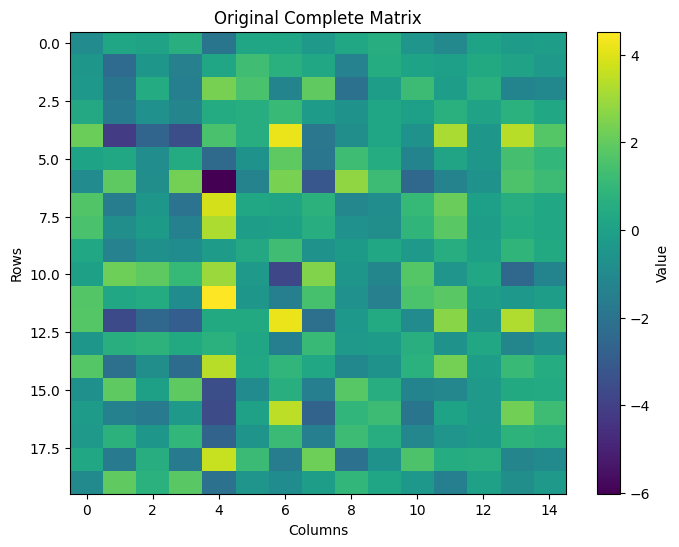

In [11]:
plt.figure(figsize=(8, 6))

plt.imshow(X_true, aspect="auto")

plt.xlabel("Columns")
plt.ylabel("Rows")
plt.title("Original Complete Matrix")

plt.colorbar(label="Value")

plt.show()

## 24. Visualize the Incomplete Matrix

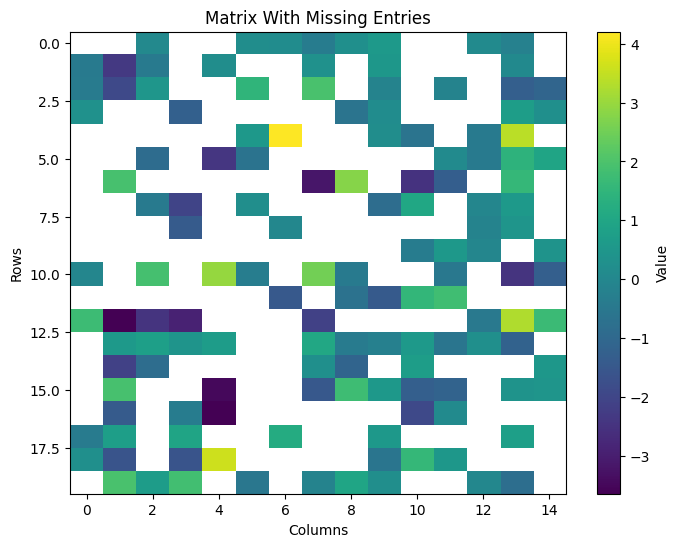

In [12]:
plt.figure(figsize=(8, 6))

plt.imshow(X_observed, aspect="auto")

plt.xlabel("Columns")
plt.ylabel("Rows")
plt.title("Matrix With Missing Entries")

plt.colorbar(label="Value")

plt.show()

## 25. Visualize the Completed Matrix

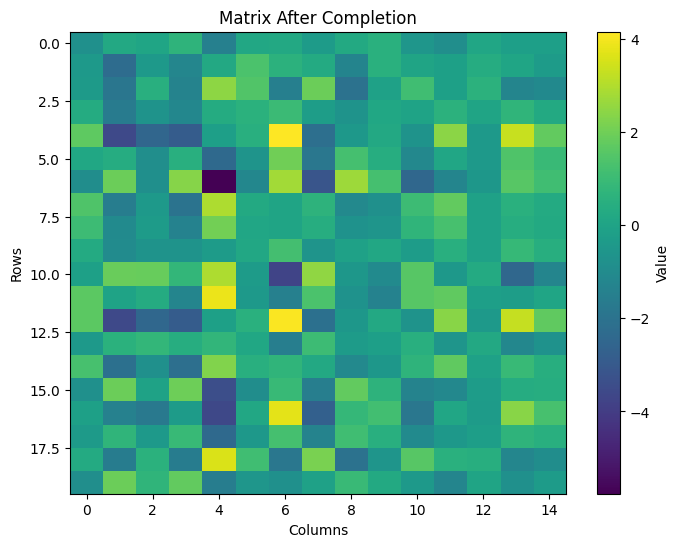

In [13]:
plt.figure(figsize=(8, 6))

plt.imshow(X_completed, aspect="auto")

plt.xlabel("Columns")
plt.ylabel("Rows")
plt.title("Matrix After Completion")

plt.colorbar(label="Value")

plt.show()

## 26. Original vs Completed Values

We can inspect several entries to understand how well the model reconstructs the matrix.

For observed entries, the model learns directly from the available values.

For missing entries, the model predicts the values using the learned latent factors.

In [14]:
comparison = pd.DataFrame({
    "Original": X_true.flatten(),
    "Completed": X_completed.flatten(),
    "Observed": mask.flatten()
})

comparison.head(20)

,Original,Completed,Observed
0,-0.928903,-0.781805,False
1,0.171905,0.230472,False
2,0.059706,0.069383,True
3,0.625760,0.679035,False
4,-1.930909,-1.446974,False
5,0.202551,0.176408,True
6,0.178110,0.213841,True
7,-0.362635,-0.318125,True
8,0.260680,0.256828,True
9,0.568980,0.521572,True


## 27. Compare Missing Entries

Let's examine only the entries that were originally hidden.

In [15]:
missing_comparison = pd.DataFrame({
    "Original": X_true[missing_mask],
    "Predicted": X_completed[missing_mask]
})

missing_comparison.head(20)

,Original,Predicted
0,-0.928903,-0.781805
1,0.171905,0.230472
2,0.625760,0.679035
3,-1.930909,-1.446974
4,-0.540421,-0.539408
5,-1.056442,-0.876750
6,-0.163768,-0.178186
7,-1.427270,-1.225605
8,1.301408,1.347682
9,0.656584,0.600473


# 28. Effect of Latent Factors

The number of latent factors $k$ controls the complexity of the model.

A small value of $k$:

- Produces a simpler model.
- May fail to capture important structure.
- Can lead to underfitting.

A large value of $k$:

- Can capture more complex patterns.
- Increases computational cost.
- Can overfit the observed entries.

Therefore, $k$ is an important hyperparameter.

In [16]:
factor_values = [1, 2, 3, 5, 8]

results = []

for k in factor_values:

    U_temp, V_temp, _ = matrix_completion(
        X_filled_for_training,
        mask,
        n_factors=k,
        learning_rate=0.01,
        regularization=0.01,
        n_epochs=500
    )

    X_temp = U_temp @ V_temp.T

    mse = mean_squared_error(
        X_true[missing_mask],
        X_temp[missing_mask]
    )

    results.append({
        "n_factors": k,
        "missing_MSE": mse
    })

results_df = pd.DataFrame(results)

results_df

,n_factors,missing_MSE
0,1,2.269759
1,2,0.494850
2,3,0.182462
3,5,0.447130
4,8,0.586724


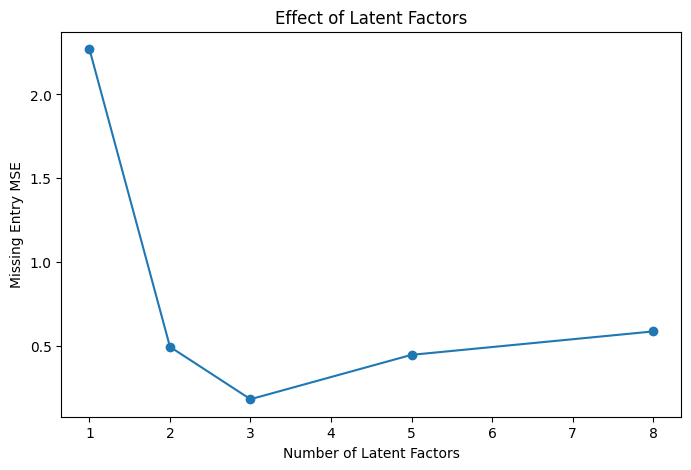

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["n_factors"],
    results_df["missing_MSE"],
    marker="o"
)

plt.xlabel("Number of Latent Factors")
plt.ylabel("Missing Entry MSE")
plt.title("Effect of Latent Factors")

plt.show()

# 29. Effect of Regularization

Regularization controls the complexity of the latent factors.

The objective is:

$$
L(U,V)
=
\text{Reconstruction Error}
+
\lambda
\left(
\|U\|_F^2 + \|V\|_F^2
\right)
$$

If $\lambda$ is too small:

- The model may overfit.
- Latent factors may become unnecessarily large.

If $\lambda$ is too large:

- The model may become too constrained.
- Important patterns may not be learned.

Therefore, $\lambda$ should usually be selected using validation data.

# 30. Matrix Completion vs Simple Imputation

### Mean Imputation

Replace missing values with the mean.

Advantages:

- Very simple
- Fast
- Easy to implement

Disadvantages:

- Ignores relationships between rows and columns
- Can destroy structure
- Often produces unrealistic values

### Matrix Completion

Uses the relationships between rows and columns.

Advantages:

- Learns latent structure
- Can capture interactions
- Useful for recommender systems
- Can provide better estimates when the low-rank assumption is reasonable

The trade-off is increased computational complexity.

# 31. Matrix Completion vs Matrix Factorization

These concepts are closely related but are not exactly identical.

### Matrix Completion

The overall problem is:

> Recover missing entries of a partially observed matrix.

### Matrix Factorization

A common technique used to solve the problem is:

$$
X \approx UV^T
$$

Therefore:

$$
\boxed{
\text{Matrix Factorization can be used for Matrix Completion}
}
$$

Matrix Completion describes the problem.

Matrix Factorization describes one important family of methods for solving it.

# 32. Applications of Matrix Completion

Matrix Completion is used in many applications.

### 1. Recommender Systems

Predict missing:

- Movie ratings
- Product ratings
- Music preferences
- User-item interactions

### 2. Collaborative Filtering

Infer user preferences from partially observed interactions.

### 3. Image Recovery

Recover missing pixels or damaged portions of an image when appropriate low-rank structure exists.

### 4. Sensor Networks

Estimate missing measurements from partially observed sensors.

### 5. Bioinformatics

Recover missing values in biological data matrices.

### 6. Financial Data

Estimate missing observations in structured financial datasets.

### 7. Network Analysis

Infer missing relationships in user-user or entity-entity interaction matrices.

# 33. Advantages of Matrix Completion

### 1. Uses Structural Information

Unlike simple imputation, Matrix Completion uses relationships between rows and columns.

### 2. Handles Large Numbers of Missing Entries

It can recover substantial portions of a matrix when enough informative observations remain.

### 3. Learns Latent Factors

Matrix factorization provides compact representations of rows and columns.

### 4. Useful for Recommendation

It is one of the fundamental ideas behind collaborative filtering.

### 5. Can Generalize to Unobserved Entries

The model can predict values that were never observed during training.

### 6. Strong Mathematical Foundation

Low-rank matrix recovery has strong connections to optimization, linear algebra, and statistical learning.

# 34. Disadvantages of Matrix Completion

### 1. Low-Rank Assumption

Matrix Completion works best when the underlying matrix is approximately low-rank.

If the matrix has no meaningful low-dimensional structure, completion may perform poorly.

### 2. Computational Cost

Large matrices can require significant computation.

### 3. Sparse Observations

If too few entries are observed, reliable recovery may be impossible.

### 4. Cold-Start Problem

New users or new items with very few observations are difficult to represent accurately.

### 5. Hyperparameter Selection

Parameters such as:

- Number of latent factors
- Learning rate
- Regularization strength
- Number of iterations

must be selected carefully.

### 6. Missingness Mechanism Matters

Matrix Completion generally assumes that the observed entries provide enough information about the underlying structure.

If missingness is highly systematic, predictions can become biased.

# 35. Important Assumptions

Matrix Completion relies on several important assumptions.

### Assumption 1 — Low-Rank Structure

The complete matrix should have approximately low rank.

$$
\operatorname{rank}(X)
\ll
\min(m,n)
$$

### Assumption 2 — Sufficient Observations

Enough entries must be observed to identify the underlying structure.

### Assumption 3 — Informative Observations

The observed entries should contain useful information about the missing entries.

### Assumption 4 — Appropriate Model Complexity

The number of latent factors should be neither too small nor unnecessarily large.

### Assumption 5 — Regularization May Be Necessary

Regularization helps control overfitting when the observed matrix is sparse.

# 36. Data Leakage in Matrix Completion

When evaluating Matrix Completion, we must carefully separate:

- Training observations
- Validation observations
- Test observations

We should never use the true values of test entries while training the model.

A correct workflow is:

$$
\text{Complete Data}
\rightarrow
\text{Observed Entries}
\rightarrow
\begin{cases}
\text{Training}\\
\text{Validation}\\
\text{Test}
\end{cases}
$$

The test entries remain hidden until final evaluation.

This is especially important because Matrix Completion is fundamentally a missing-data prediction problem.

# 37. Comparison of Missing Value Methods

| Method | Uses Row/Column Relationships | Learns Latent Structure | Handles Sparse Matrix | Complexity |
|---|---|---|---|---|
| Mean Imputation | No | No | Yes | Very Low |
| Median Imputation | No | No | Yes | Very Low |
| KNN Imputation | Yes | Limited | Moderate | Medium |
| Regression Imputation | Yes | Limited | Moderate | Medium |
| Matrix Factorization | Yes | Yes | Yes | Medium/High |
| Nuclear Norm Completion | Yes | Yes | Yes | High |

Matrix Completion is particularly useful when the matrix has meaningful low-dimensional structure.

# 38. Mathematical Summary

We observe only:

$$
P_{\Omega}(X)
$$

We assume:

$$
X \approx UV^T
$$

We optimize:

$$
\min_{U,V}
\sum_{(i,j)\in\Omega}
\left(
X_{ij} - U_i^T V_j
\right)^2
+
\lambda
\left(
\|U\|_F^2+\|V\|_F^2
\right)
$$

After optimization:

$$
\hat{X}=UV^T
$$

The missing entries are obtained from:

$$
\hat{X}_{ij}
=
U_i^T V_j
$$

for entries $(i,j)$ that were not observed.

# 39. Connection With Previous Topics

Matrix Completion connects several important machine learning concepts.

### Matrix Factorization

$$
X \approx UV^T
$$

provides the basic representation.

### PCA

PCA searches for low-dimensional structure using orthogonal directions.

### Low-Rank Approximation

Matrix Completion assumes that the underlying matrix can be approximated by a low-rank matrix.

### Collaborative Filtering

User-item recommendation can be formulated as a matrix completion problem.

### Regularization

Regularization prevents the latent factors from becoming unnecessarily complex.

### Optimization

The latent factors are learned by minimizing an objective function.

Therefore, Matrix Completion is an important bridge between:

$$
\boxed{
\text{Linear Algebra}
+
\text{Optimization}
+
\text{Unsupervised Learning}
}
$$

# 40. Summary

Matrix Completion aims to recover missing entries of a partially observed matrix.

The central assumption is:

$$
\operatorname{rank}(X)
\ll
\min(m,n)
$$

A common approach is Matrix Factorization:

$$
X \approx UV^T
$$

The model learns latent representations for rows and columns.

The optimization objective is:

$$
\min_{U,V}
\sum_{(i,j)\in\Omega}
\left(
X_{ij}-U_i^TV_j
\right)^2
+
\lambda
\left(
\|U\|_F^2+\|V\|_F^2
\right)
$$

Important concepts:

- Observed entries
- Missing entries
- Observation mask
- Low-rank structure
- Matrix factorization
- Latent factors
- Reconstruction error
- Regularization
- Nuclear norm
- Collaborative filtering
- Cold-start problem
- Data leakage

Matrix Completion is especially useful when a large incomplete matrix contains a strong low-dimensional structure.

# 41. Key Takeaways

1. Matrix Completion predicts missing entries of a matrix.

2. It assumes that the underlying matrix has low-dimensional structure.

3. A common formulation is:

$$
X \approx UV^T
$$

4. Only observed entries should contribute to the reconstruction loss.

5. Regularization helps prevent overfitting.

6. The number of latent factors controls model complexity.

7. Nuclear norm minimization provides a convex approach to low-rank recovery.

8. Matrix Completion is fundamental to collaborative filtering and recommender systems.

9. Evaluation must be performed on held-out entries that were not used during training.

10. Matrix Completion works best when sufficient observations reveal the underlying low-rank structure.